In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("Reviews.csv")

In [4]:
df.head(10)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...
5,6,B006K2ZZ7K,ADT0SRK1MGOEU,Twoapennything,0,0,4,1342051200,Nice Taffy,I got a wild hair for taffy and ordered this f...
6,7,B006K2ZZ7K,A1SP2KVKFXXRU1,David C. Sullivan,0,0,5,1340150400,Great! Just as good as the expensive brands!,This saltwater taffy had great flavors and was...
7,8,B006K2ZZ7K,A3JRGQVEQN31IQ,Pamela G. Williams,0,0,5,1336003200,"Wonderful, tasty taffy",This taffy is so good. It is very soft and ch...
8,9,B000E7L2R4,A1MZYO9TZK0BBI,R. James,1,1,5,1322006400,Yay Barley,Right now I'm mostly just sprouting this so my...
9,10,B00171APVA,A21BT40VZCCYT4,Carol A. Reed,0,0,5,1351209600,Healthy Dog Food,This is a very healthy dog food. Good for thei...


In [5]:
df.shape

(568454, 10)

In [6]:
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

In [7]:
df['Text'].head()

0    I have bought several of the Vitality canned d...
1    Product arrived labeled as Jumbo Salted Peanut...
2    This is a confection that has been around a fe...
3    If you are looking for the secret ingredient i...
4    Great taffy at a great price.  There was a wid...
Name: Text, dtype: object

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568438 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [9]:
df = df.head(5000)

In [10]:
df.shape

(5000, 10)

In [11]:
df.to_csv("Reviews_5000.csv", index=False)

## 🔄 Preparing Data for Cleaning

Before proceeding to data cleaning, the dataset was limited to the first **5000 rows** as per the project requirements. This helps in reducing computational load and ensures faster processing while maintaining a representative sample of the data.

The trimmed dataset was also saved as a separate file (`Reviews_5000.csv`) for submission purposes.

### ✅ Status:
- Dataset successfully loaded
- Limited to 5000 rows
- Initial exploration completed
- Dataset saved for further processing

The dataset is now ready for the data cleaning phase.

In [12]:
df.isnull().sum()

Id                        0
ProductId                 0
UserId                    0
ProfileName               0
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Score                     0
Time                      0
Summary                   0
Text                      0
dtype: int64

In [13]:
df = df.dropna(subset=['Text'])

In [14]:
df = df.drop_duplicates(subset=['Text'])

In [15]:
df = df[['Text', 'Score']]

In [16]:
df.shape


(4984, 2)

In [17]:
df.head()

,Text,Score
0,I have bought several of the Vitality canned d...,5
1,Product arrived labeled as Jumbo Salted Peanut...,1
2,This is a confection that has been around a fe...,4
3,If you are looking for the secret ingredient i...,2
4,Great taffy at a great price. There was a wid...,5


In [18]:
df.to_csv("Reviews_5000.csv", index=False)

## 🧹 Task 2: Data Cleaning

### 🔍 Overview
In this step, the dataset was cleaned to ensure high-quality data for sentiment analysis.

### 🧼 Cleaning Steps Performed:
- Removed rows with missing or empty review text to ensure meaningful analysis
- Removed duplicate reviews to avoid bias in sentiment results
- Selected only the relevant columns: **'Text'** (review content) and **'Score'** (rating)

### 📌 Result:
- The dataset is now free from null values and duplicates
- Only essential columns are retained for further analysis

### 🧠 Key Insight:
Cleaning the dataset improves the accuracy of sentiment analysis and ensures that the results are reliable and unbiased.

In [19]:
!pip install textblob

Defaulting to user installation because normal site-packages is not writeable


In [20]:
from textblob import TextBlob

In [21]:
def get_sentiment_score(text):
    return TextBlob(text).sentiment.polarity

In [22]:
df['Sentiment_Score'] = df['Text'].apply(get_sentiment_score)

In [23]:
def get_sentiment_label(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

In [24]:
df['Sentiment'] = df['Sentiment_Score'].apply(get_sentiment_label)

In [25]:
df.head()

,Text,Score,Sentiment_Score,Sentiment
0,I have bought several of the Vitality canned d...,5,0.450000,Positive
1,Product arrived labeled as Jumbo Salted Peanut...,1,-0.033333,Negative
2,This is a confection that has been around a fe...,4,0.133571,Positive
3,If you are looking for the secret ingredient i...,2,0.166667,Positive
4,Great taffy at a great price. There was a wid...,5,0.483333,Positive


In [26]:
df['Sentiment'].value_counts()

Positive    4403
Negative     501
Neutral       80
Name: Sentiment, dtype: int64

In [27]:
df.to_csv("Reviews_5000.csv", index=False)

## 😊 Task 3: Sentiment Analysis

### 🔍 Overview
In this step, sentiment analysis was performed on the review text using the TextBlob library.

### ⚙️ Process:
- Calculated sentiment polarity score for each review
- The polarity score ranges from -1 to +1:
  - Negative sentiment → score < 0
  - Neutral sentiment → score = 0
  - Positive sentiment → score > 0
- Based on the polarity score, each review was classified into Positive, Negative, or Neutral

### 📌 Result:
- A new column **'Sentiment_Score'** was created to store polarity values
- A new column **'Sentiment'** was created to store sentiment labels

### 🧠 Key Insight:
Sentiment analysis helps in automatically understanding customer opinions at scale, making it easier to identify overall satisfaction trends.

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
import os
os.makedirs("charts", exist_ok=True)

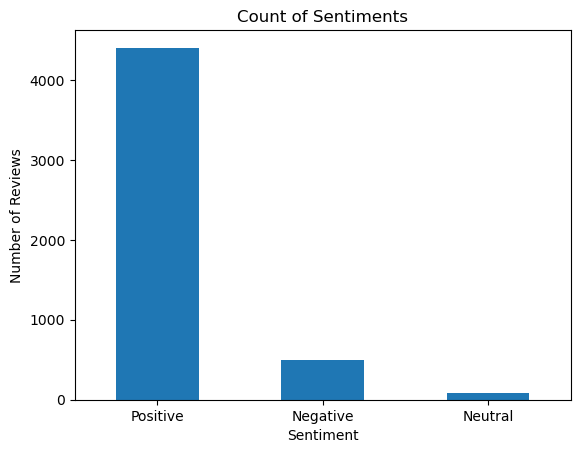

In [33]:
sentiment_counts = df['Sentiment'].value_counts()

plt.figure()
sentiment_counts.plot(kind='bar')
plt.title("Count of Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)

plt.savefig("charts/bar_chart.png")
plt.show()

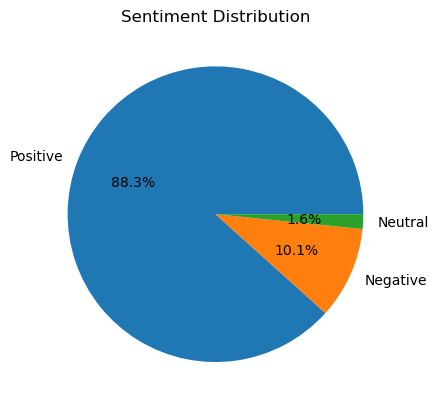

In [34]:
plt.figure()
sentiment_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Sentiment Distribution")
plt.ylabel("")

plt.savefig("charts/pie_chart.png")
plt.show()

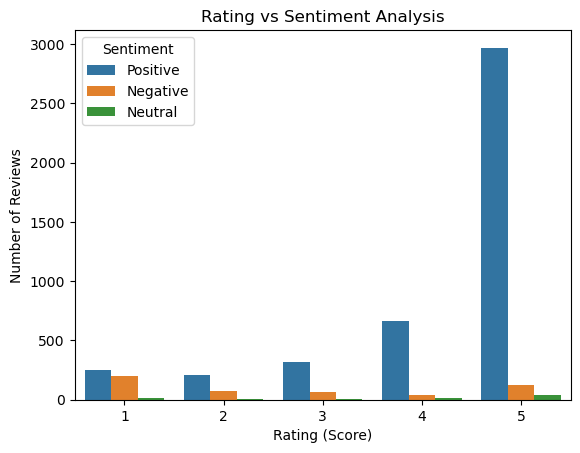

In [35]:
plt.figure()

sns.countplot(data=df, x='Score', hue='Sentiment')

plt.title("Rating vs Sentiment Analysis")
plt.xlabel("Rating (Score)")
plt.ylabel("Number of Reviews")

plt.savefig("charts/rating_vs_sentiment.png")
plt.show()

## 📊 Task 4: Data Visualization

### 🔍 Overview
In this step, visualizations were created to better understand the distribution of sentiments in the dataset.

### 📈 Charts Created:

1. **Bar Chart**
   - Displays the count of Positive, Negative, and Neutral reviews
   - Helps identify which sentiment is most common

2. **Pie Chart**
   - Shows the percentage distribution of sentiments
   - Provides a quick overview of overall customer satisfaction

3. **Rating vs Sentiment Chart**
   - Compares user ratings with sentiment classification
   - Helps analyze how sentiment aligns with actual ratings

### 🧠 Key Insight:
Visualizations make it easier to identify patterns and trends in customer feedback, enabling better business decisions.

In [36]:
df['Sentiment'].value_counts(normalize=True) * 100

Positive    88.342697
Negative    10.052167
Neutral      1.605136
Name: Sentiment, dtype: float64

## 🧠 Task 5: Insights & Summary

### 📊 Key Findings:

- Approximately **88.34%** of the reviews are Positive, indicating that most customers are satisfied with the products.
- Around **10.05%** of the reviews are Negative, showing that a smaller portion of customers had poor experiences.
- Neutral reviews account for about **1.60%**, representing mixed or unclear opinions.

### ❗ Customer Complaints:
Negative reviews commonly mention issues such as poor taste, packaging problems, expired or damaged products, and dissatisfaction with product quality.

### 😲 Surprising Observation:
One interesting observation is that some reviews with lower ratings still have slightly positive sentiment scores, indicating that textual sentiment and numerical ratings do not always perfectly align.

### 💡 Recommendation:
The business should focus on improving product quality and packaging, as these are common concerns in negative reviews. Additionally, monitoring sentiment trends can help quickly identify and address customer issues.